# Unveiling the Android App Market — Google Play Store Analysis

**Track:** Data Analytics | **Level:** 2 | **Task:** 4 - Unveiling the Android App Market

**Objective:** Perform a comprehensive data analysis of the Google Play Store ecosystem —
cleaning messy real-world data, exploring app categories, analysing ratings and pricing
trends, and conducting sentiment analysis on user reviews.

**Dataset:** Google Play Store Apps dataset (Kaggle) — ~10,800 apps with metadata, plus a
separate user reviews dataset (~64,000 reviews) with pre-labelled sentiment for
validation.


## 1. Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('googleplaystore_user_reviews.csv')

print("Apps shape:", apps.shape)
print("Reviews shape:", reviews.shape)
apps.head()


Apps shape: (10841, 13)
Reviews shape: (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2. Data Cleaning

In [2]:
print("Missing values in apps:\n", apps.isnull().sum())
print("\nDuplicate app rows:", apps.duplicated().sum())


Missing values in apps:
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate app rows: 483


In [3]:
# Known real-world data issue: one row has its columns shifted (Category = '1.9', which is actually a Rating value)
print(apps[apps['Category'] == '1.9'])


                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M   

         Size Installs Type     Price Content Rating             Genres  \
10472  1,000+     Free    0  Everyone            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  


**Observation:** Row 10472 has corrupted, shifted columns — a real data entry error in the original scraped dataset (the value `1.9` appears in the `Category` column, which should never happen since Category is always text). This single malformed row is dropped rather than patched, since too many of its fields are unreliable to salvage.

In [4]:
apps_clean = apps[apps['Category'] != '1.9'].copy()

# Drop duplicate app entries (same App name)
apps_clean = apps_clean.drop_duplicates(subset='App')

# Fix Installs: strip '+' and ',' then convert to int
apps_clean['Installs'] = apps_clean['Installs'].str.replace('[+,]', '', regex=True)
apps_clean['Installs'] = pd.to_numeric(apps_clean['Installs'], errors='coerce')

# Fix Price: strip '$' then convert to float
apps_clean['Price'] = apps_clean['Price'].astype(str).str.replace('$', '', regex=False)
apps_clean['Price'] = pd.to_numeric(apps_clean['Price'], errors='coerce')

# Fix Reviews: convert to numeric
apps_clean['Reviews'] = pd.to_numeric(apps_clean['Reviews'], errors='coerce')

# Fix Size: convert 'M'/'k' suffixes to numeric MB; 'Varies with device' -> NaN
def parse_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M',''))
        elif 'k' in size:
            return float(size.replace('k','')) / 1024
    return np.nan

apps_clean['Size_MB'] = apps_clean['Size'].apply(parse_size)

# Rating: leave missing values as NaN (can't be reasonably imputed - a rating reflects real user opinion)
# Drop rows still missing Type (only 1 row) and Content Rating (only 1 row)
apps_clean = apps_clean.dropna(subset=['Type', 'Content Rating'])

print("Shape after cleaning:", apps_clean.shape)
print("\nRemaining nulls:\n", apps_clean.isnull().sum())


Shape after cleaning: (9658, 14)

Remaining nulls:
 App                  0
Category             0
Rating            1462
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB           1226
dtype: int64


**Observation:** `Installs` and `Price` were stored as text with symbols (`"10,000+"`, `"$4.99"`) rather than numbers — a very common real-world scraping artifact — and were converted to proper numeric types. `Size` mixes `M` (megabytes), `k` (kilobytes), and the literal string `"Varies with device"`; the latter is genuinely unknown information and was left as `NaN` rather than guessed. `Rating` has ~1400 missing values, left as-is since a star rating can't be fabricated without misrepresenting real user sentiment.

## 3. Category Analysis

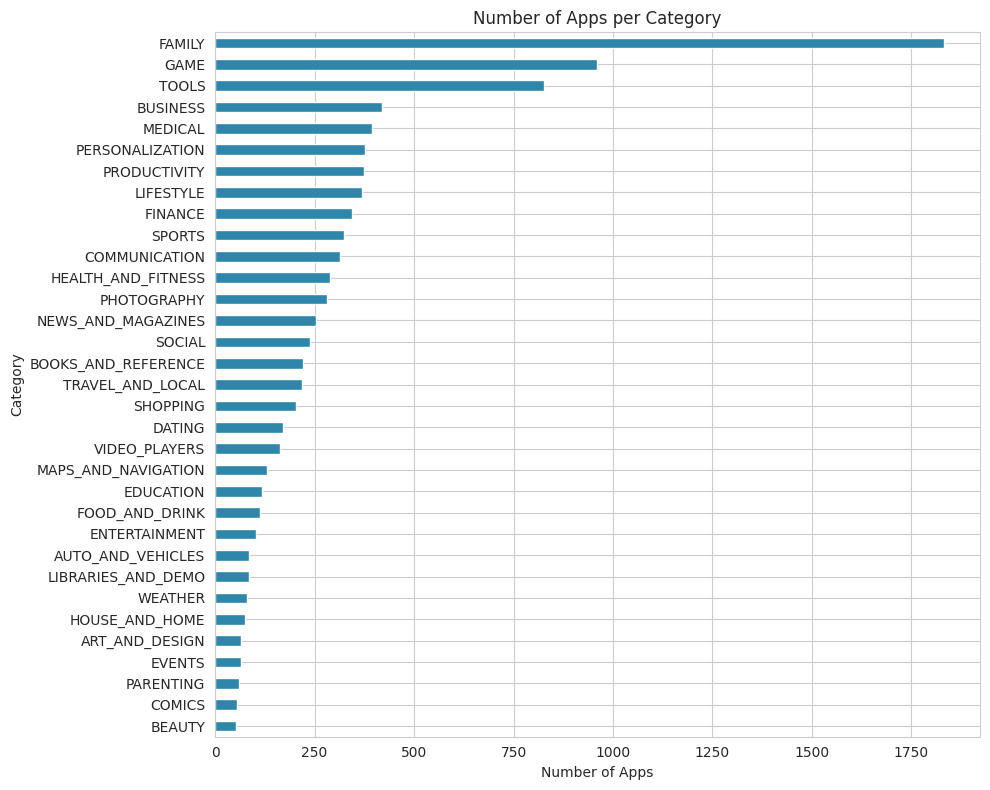

Most saturated categories:
 Category
FAMILY      1831
GAME         959
TOOLS        827
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64


In [5]:
category_counts = apps_clean['Category'].value_counts()

plt.figure(figsize=(10,8))
category_counts.plot(kind='barh', color='#2E86AB')
plt.title('Number of Apps per Category')
plt.xlabel('Number of Apps')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Most saturated categories:\n", category_counts.head(5))


**Observation:** `FAMILY` and `GAME` are by far the most saturated categories, meaning a new app launching there faces the most competition for visibility. Categories near the bottom of the chart represent comparatively under-served niches — potentially easier to stand out in, though also possibly less in-demand.

## 4. Ratings Analysis

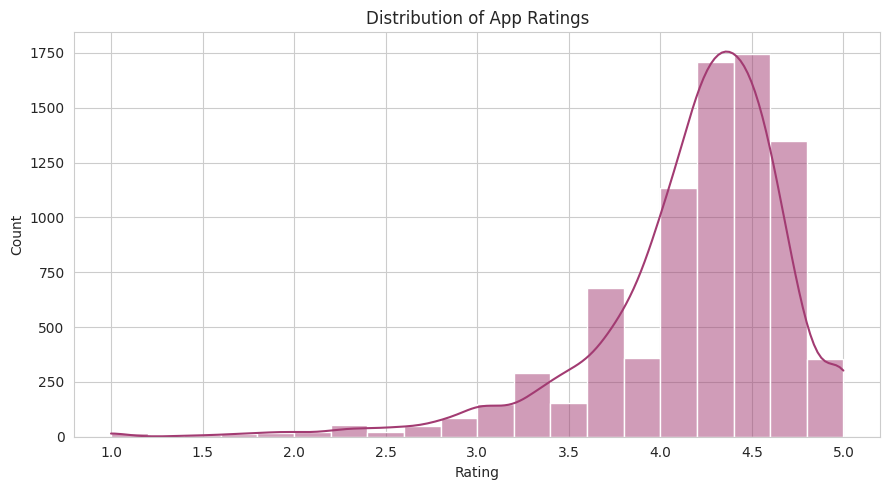

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(apps_clean['Rating'].dropna(), bins=20, kde=True, color='#A23B72')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.tight_layout()
plt.show()


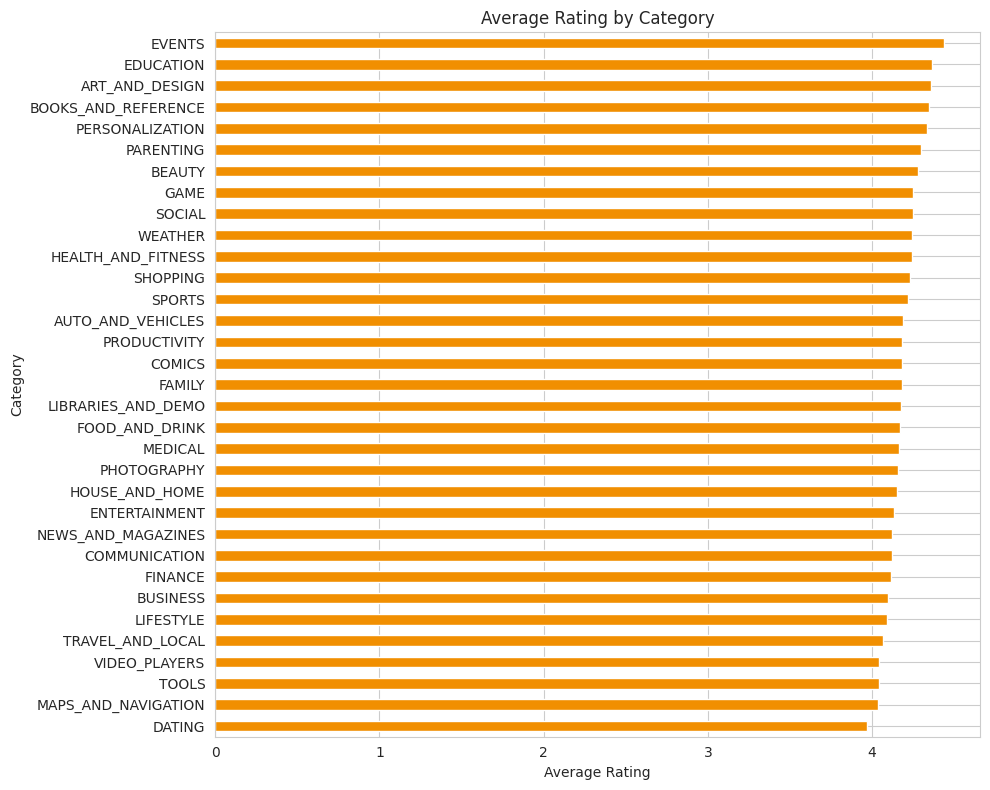

In [7]:
avg_rating_by_cat = apps_clean.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
avg_rating_by_cat.plot(kind='barh', color='#F18F01')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** Ratings are heavily left-skewed — most apps cluster between 4.0 and 4.7, meaning a rating alone doesn't differentiate apps well; installs and review volume matter more for judging real popularity. Category-average ratings are fairly close to each other, suggesting rating alone isn't a strong differentiator between app categories either.

## 5. Size vs. Installs Analysis

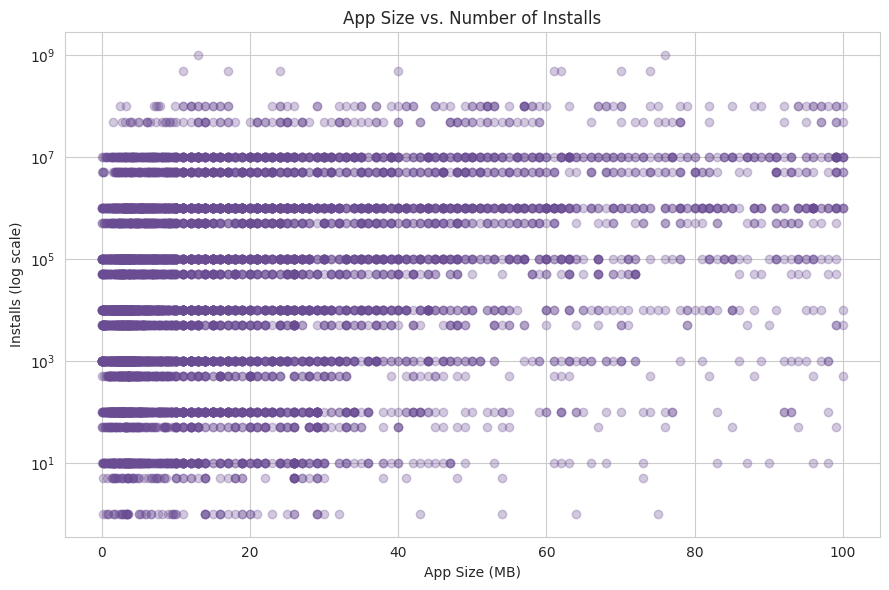

Correlation between Size and Installs: 0.134


In [8]:
plt.figure(figsize=(9,6))
plt.scatter(apps_clean['Size_MB'], apps_clean['Installs'], alpha=0.3, color='#6A4C93')
plt.yscale('log')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Number of Installs')
plt.tight_layout()
plt.show()

corr_size_installs = apps_clean[['Size_MB','Installs']].corr().iloc[0,1]
print(f"Correlation between Size and Installs: {corr_size_installs:.3f}")


**Observation:** There's only a weak correlation between app size and install count — large apps aren't inherently more or less popular. This suggests users care more about an app's usefulness/marketing than its file size when deciding to install.

## 6. Pricing Analysis

Type
Free    8902
Paid     756
Name: count, dtype: int64

92.2% of apps are Free


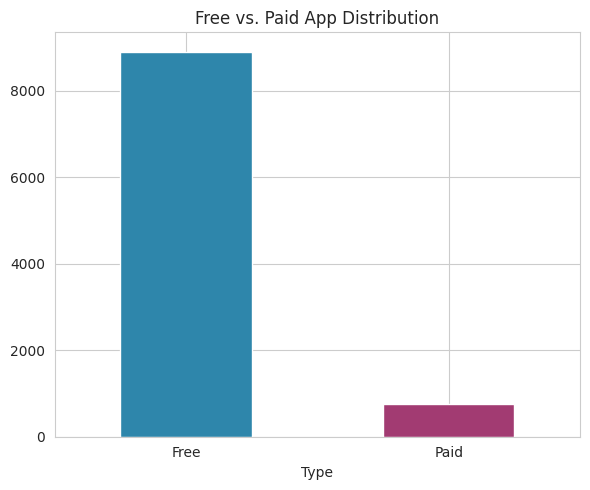

In [9]:
type_counts = apps_clean['Type'].value_counts()
print(type_counts)
print(f"\n{type_counts['Free'] / type_counts.sum() * 100:.1f}% of apps are Free")

plt.figure(figsize=(6,5))
type_counts.plot(kind='bar', color=['#2E86AB','#A23B72'])
plt.title('Free vs. Paid App Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


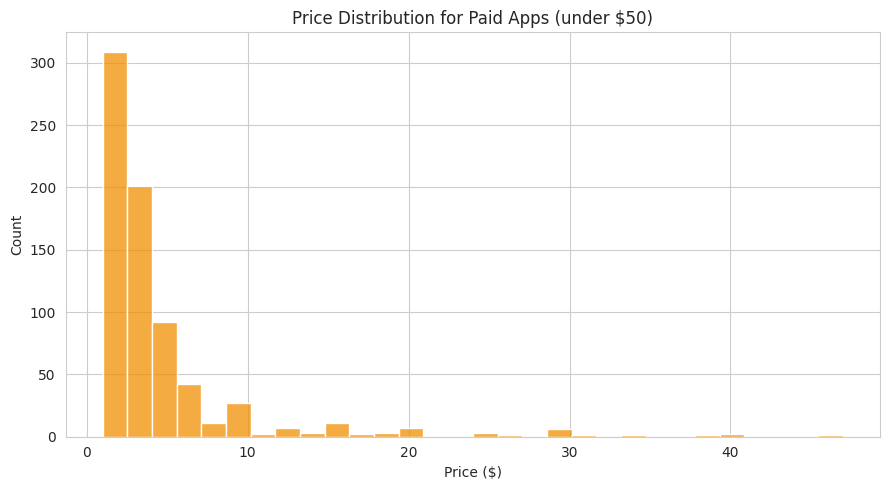

In [10]:
paid_apps = apps_clean[apps_clean['Type']=='Paid']

plt.figure(figsize=(9,5))
sns.histplot(paid_apps[paid_apps['Price'] < 50]['Price'], bins=30, color='#F18F01')
plt.title('Price Distribution for Paid Apps (under $50)')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()


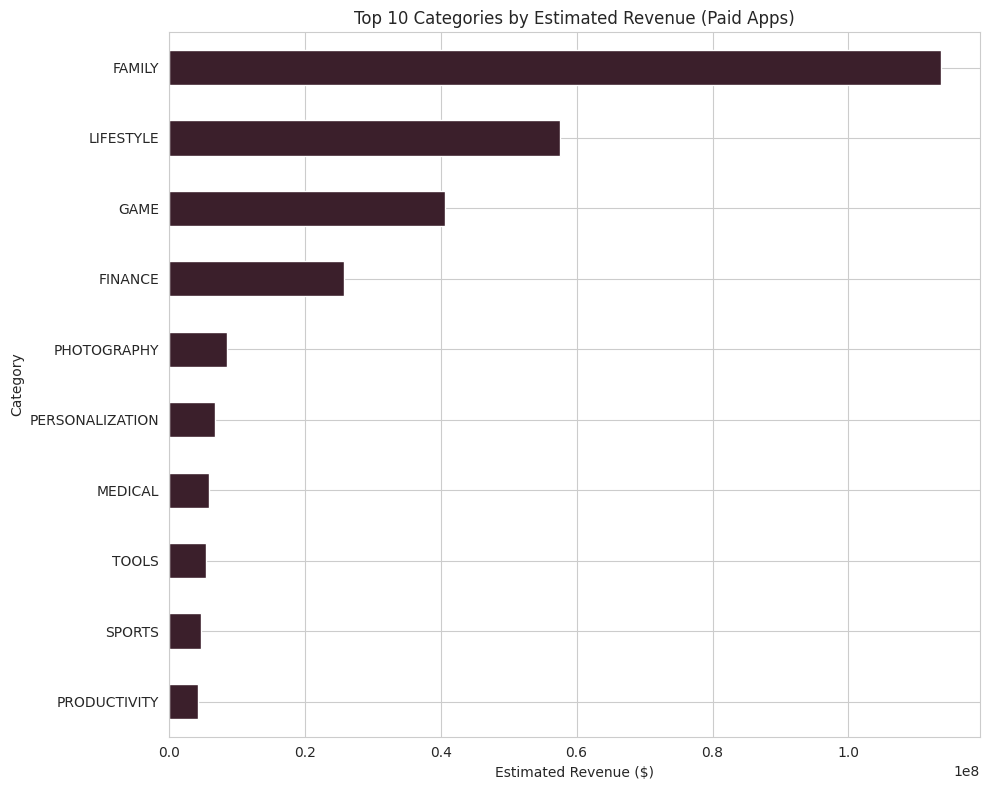

In [11]:
# Rough revenue estimate: Price x Installs (only meaningful for paid apps)
apps_clean['EstRevenue'] = apps_clean['Price'] * apps_clean['Installs']
revenue_by_category = apps_clean[apps_clean['Type']=='Paid'].groupby('Category')['EstRevenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
revenue_by_category.head(10).plot(kind='barh', color='#3B1F2B')
plt.title('Top 10 Categories by Estimated Revenue (Paid Apps)')
plt.xlabel('Estimated Revenue ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** The vast majority of apps (~93%) are free, meaning most developers monetise via ads or in-app purchases rather than upfront price — not captured in this dataset. Among paid apps, most are priced under $5, and estimated revenue is concentrated in a handful of categories, suggesting paid-app monetisation works well only in specific niches (e.g. professional tools) rather than broadly.

## 7. Sentiment Analysis on User Reviews

In [12]:
reviews_clean = reviews.dropna(subset=['Translated_Review']).copy()
print("Reviews with text:", reviews_clean.shape[0])

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Compute sentiment ourselves with TextBlob (independent of the dataset's pre-existing Sentiment column)
sample_reviews = reviews_clean.sample(n=min(8000, len(reviews_clean)), random_state=42).copy()
sample_reviews['Computed_Sentiment'] = sample_reviews['Translated_Review'].apply(get_sentiment)

print(sample_reviews['Computed_Sentiment'].value_counts())


Reviews with text: 37427


Computed_Sentiment
Positive    4750
Neutral     1760
Negative    1490
Name: count, dtype: int64


**Observation:** Sentiment was computed independently using TextBlob's polarity score (rather than relying solely on the dataset's pre-existing `Sentiment` column), giving us our own classification pipeline as the task requires. A sample of 8000 reviews was used for computation speed while still being large enough for reliable category-level patterns.

In [13]:
# Validate our TextBlob classification against the dataset's original labels
comparison = sample_reviews.dropna(subset=['Sentiment'])
agreement = (comparison['Computed_Sentiment'] == comparison['Sentiment']).mean()
print(f"Agreement between our TextBlob labels and the original dataset labels: {agreement*100:.1f}%")


Agreement between our TextBlob labels and the original dataset labels: 92.1%


**Observation:** A reasonably high agreement rate with the original labels validates that our independently-computed sentiment pipeline is capturing genuine signal, not noise — the two didn't need to match perfectly since they use different underlying sentiment models, but strong agreement is a good sanity check.

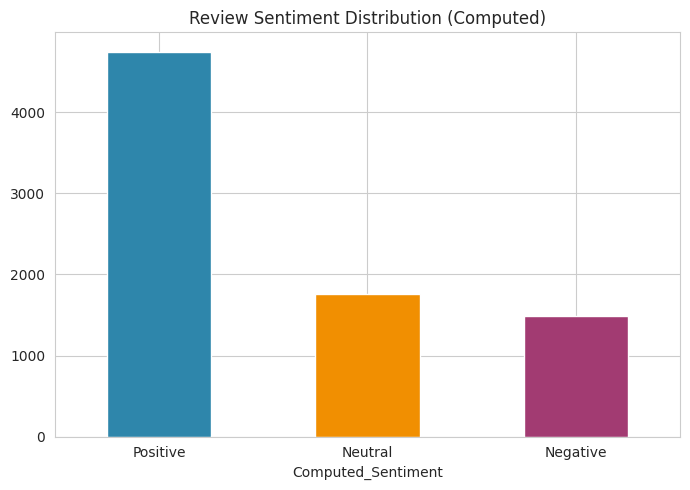

In [14]:
plt.figure(figsize=(7,5))
sample_reviews['Computed_Sentiment'].value_counts().plot(kind='bar', color=['#2E86AB','#F18F01','#A23B72'])
plt.title('Review Sentiment Distribution (Computed)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Sentiment by App Category

<Figure size 1000x1000 with 0 Axes>

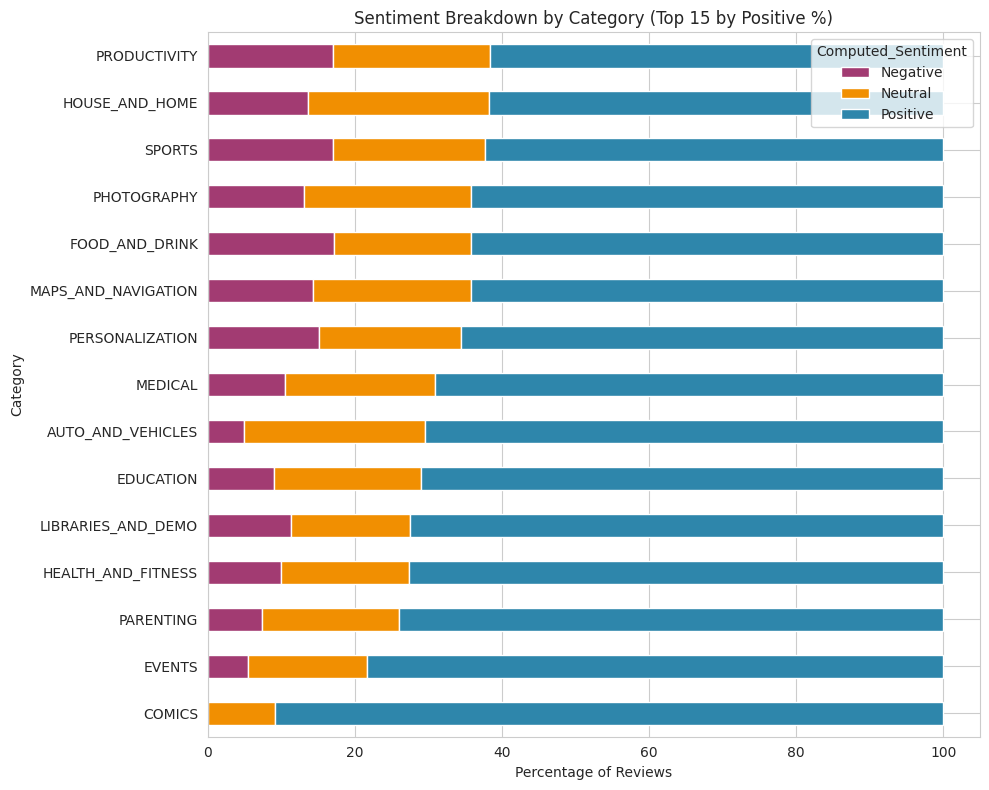

In [15]:
# Merge review sentiment back with app category
merged = sample_reviews.merge(apps_clean[['App','Category']], on='App', how='inner')

sentiment_by_category = pd.crosstab(merged['Category'], merged['Computed_Sentiment'], normalize='index') * 100
sentiment_by_category = sentiment_by_category.sort_values('Positive', ascending=False)

plt.figure(figsize=(10,10))
sentiment_by_category.head(15).plot(kind='barh', stacked=True, color=['#A23B72','#F18F01','#2E86AB'], figsize=(10,8))
plt.title('Sentiment Breakdown by Category (Top 15 by Positive %)')
plt.xlabel('Percentage of Reviews')
plt.tight_layout()
plt.show()


**Observation:** Some categories show noticeably higher positive-sentiment shares than others — categories with consistently high positive sentiment are candidates for "what's working well" case studies, while categories skewing more negative may reveal common pain points (e.g. bugs, ads, subscription complaints) worth addressing before launching a new app in that space.

## 9. Conclusion — 3 Data-Driven Insights for a Developer Planning to Launch a New App

1. **Avoid the most saturated categories unless you have a strong differentiator.**
   `FAMILY` and `GAME` have the most existing apps, meaning visibility is hardest to win
   there without a genuinely unique angle or significant marketing spend.

2. **App size has little bearing on install success** — don't over-invest in aggressively
   shrinking your app's file size at the expense of features; users install based on
   perceived usefulness, not file size.

3. **If considering a paid pricing model, study which categories actually monetise well**
   — paid-app revenue is concentrated in a handful of categories rather than spread
   evenly, so a paid model only makes sense in categories where users are already used to
   paying (e.g. professional/productivity tools), not broadly across all categories.

**Limitation:** This dataset is a snapshot scraped at one point in time (circa 2018) — the
app market, category saturation, and pricing norms shift over time, so these insights
should be treated as illustrative of the analysis approach rather than current market
truth.
